# PRCP- 1001- Rice Leaf Disease Detection
Business Statement :
Classify the three major attacking diseases of rice plants like leaf blast, bacterial blight and brown spot.

# Problem Statement

# Task 1:-Prepare a complete data analysis report on the given data.
The case is an image multiclass classification, so there are no features to be analyzed with EDA.
Information regarding three rice plants diseases above from wikipeda are :
From wikipedia :
- Leaf blast, or Magnaporthe grisea, also known as rice blast fungus is a plant-pathogenic fungus and model organism that causes a serious disease affecting rice
- Bacterial blight, or Xanthomonas oryzae pv. oryzae is a bacterial pathovar that causes a serious blight of rice, other grasses, and sedges.
- Brown spot, or Cochliobolus miyabeanus (teleomorph) is a fungus that causes brown spot disease in rice.

# Task 2:-Create a model which can classify the three major attacking diseases of rice plants like leaf blast, bacterial blight and brown spot.

In [1]:
# import modules needed
import numpy as np
import os # import os module
from zipfile import ZipFile #import zipfile module
import matplotlib.pyplot as plt
from PIL import Image # to import image
from sklearn.model_selection import train_test_split # for splitting the data
import shutil # to copy file
import keras # for image processing
import tensorflow as tf
import time # to count time needed to process the models

# Step 1 : Data Preparation

## 1.1 Reproducible Result
## Everytime we run in the models, the results always different even with the same parameter. To make a reproducible result, we have to specify some parameters here:

ref : https://keras.io/getting_started/faq/#how-can-i-obtain-reproducible-results-using-keras-during-developmentrandom-seeds]

In [2]:
# Seed value
seed_value= 1337 # random number
keras.utils.set_random_seed(seed_value)

# Enable operation-level determinism
tf.config.experimental.enable_op_determinism()

# to make PYTHONHASHSEED
# For Windows:
# open anaconda prompt and 'set PYTHONHASHSEED=0'
# Then proceed to execute our Python script or launch a Jupyter Notebook within the same prompt window.

## 1.2 File Extraction
Dataset is stored in zip file namely 'PRCP-1001-RiceLeaf.zip' and it contain one folder 'Data'. In the 'Data' folder there are three zip files, each of them has a folder name of the paddy leaf rice disease. We will extract those 3 zip files to a folder namely 'data_extraction'.

In [3]:
# Extract file
with ZipFile('PRCP-1001-RiceLeaf.zip', 'r') as zObject :
    zObject.extractall()

# Data source folder 
source_folder = 'Data'

# Folder destination to extract all contents
destination_folder = 'data_extraction'

# List all zip files in the source folder
zip_files = [f for f in os.listdir(source_folder) if f.endswith('.zip')]

# Iterate through each zip file and extract its contents to the destination folder
for x in zip_files :
    zip_file_path = os.path.join(source_folder, x)
    
    with ZipFile(zip_file_path, 'r') as zip_ref:
        # Extract all contents to the specified destination folder
        zip_ref.extractall(destination_folder)

## 1.3 Sample Preview

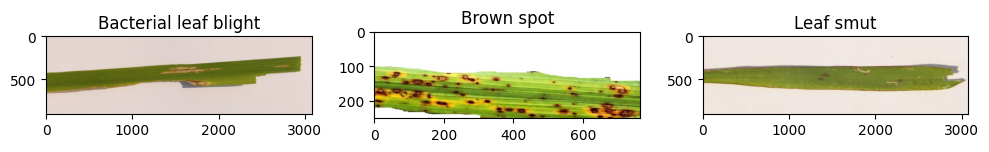

In [4]:
data_dir = 'data_extraction'  

# There are three classes: Bacterial leaf blight, Brown spot, Leaf smut
classes = os.listdir(data_dir)

# Visualization  
plt.figure(figsize=(10, 5))

for i, class_name in enumerate(classes):
    class_path = os.path.join(data_dir, class_name) # create a path to every 3 classes in folder 'data_extraction' directory
    sample_image = os.listdir(class_path)[0]  # Load the first image from each class
    image_path = os.path.join(class_path, sample_image)
    
    # Load and display the image
    image = Image.open(image_path)
    plt.subplot(1, 3, i+1)
    plt.imshow(image)
    plt.title(class_name)

plt.tight_layout()
plt.show()

## 1.4 Create Training-Validation-Test folders
Splitting the data to three folders, training/validation/test folders with split ratio 80%-10%-10%. Each of them has three classes of leaf diseases.

In [5]:
# Original dataset directory
data_dir = 'data_extraction' 

# Directory to create train/validation/test split
base_dir = 'model_dataset'
os.makedirs(base_dir, exist_ok=True)

# Create directories for training, validation, and test data in folder 'model_dataset'
train_dir = os.path.join(base_dir, 'train')
val_dir = os.path.join(base_dir, 'val')
test_dir = os.path.join(base_dir, 'test')

# Create directories if they don't exist
for directory in [train_dir, val_dir, test_dir]:
    os.makedirs(directory, exist_ok=True)

# Loop through classes in the original dataset
for class_name in os.listdir(data_dir):
    class_dir = os.path.join(data_dir, class_name)

    # Split data for each class into training, validation, and test sets (80% - 10% - 10%)
    train_class_dir, test_class_dir = train_test_split(os.listdir(class_dir), test_size=0.2, random_state=42) # split to train & test
    val_class_dir, test_class_dir = train_test_split(test_class_dir, test_size=0.5, random_state=42) # split test to validation & test

    # Copy images to respective directories for each class
    for fname in train_class_dir:
        src = os.path.join(class_dir, fname)
        dst = os.path.join(train_dir, class_name, fname)
        os.makedirs(os.path.join(train_dir, class_name), exist_ok=True)
        shutil.copyfile(src, dst) # to copy the content of the source file to the destination file
    
    for fname in val_class_dir:
        src = os.path.join(class_dir, fname)
        dst = os.path.join(val_dir, class_name, fname)
        os.makedirs(os.path.join(val_dir, class_name), exist_ok=True)
        shutil.copyfile(src, dst)
    
    for fname in test_class_dir:
        src = os.path.join(class_dir, fname)
        dst = os.path.join(test_dir, class_name, fname)
        os.makedirs(os.path.join(test_dir, class_name), exist_ok=True)
        shutil.copyfile(src, dst)


# Step 2: Create the Model

## 2.1 Basic Model with no Augmentation

In [6]:
# Import additional modules
from tensorflow.keras.models import Sequential # to create models layer-by-layer in a step-by-step fashion.
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.optimizers import Adam # Optimizer normally used
from tensorflow.keras.losses import categorical_crossentropy # analysis for multiclass classification
from tensorflow.keras.metrics import Accuracy # metric used to evaluate the performance of a model
from tensorflow.keras.preprocessing.image import ImageDataGenerator # generates batches of image files

In [7]:
# Define CNN model architecture 
model = Sequential([        # Initializes a Sequential model
    # Convolutional layers with ReLU activation to extract features
    Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)),
    # Creates a Convolutional 2D layer with 32 filters, each using a 3x3 kernel/filter, 
    # ReLU activation function, and an input shape of (150, 150, 3) representing 150x150 RGB images
    
    # Adds a MaxPooling layer with a 2x2 pooling window for downsampling the feature maps
    MaxPooling2D((2, 2)), 
        
    Flatten(), # Flattening layer to convert the 2D feature maps into a 1D vector
    Dense(128, activation='relu'), # Adds a fully connected layer with 128 neurons and ReLU activation.
    
    # Final output layer with 3 neurons (representing 3 classes) and softmax activation for multi-class classification
    Dense(3, activation='softmax')  
    ])

# Compiling the model with 'adam' optimizer and 'categorical_crossentropy' loss for multiple classes
model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

# Display the model summary
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 148, 148, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2  (None, 74, 74, 32)        0         
 D)                                                              
                                                                 
 flatten (Flatten)           (None, 175232)            0         
                                                                 
 dense (Dense)               (None, 128)               22429824  
                                                                 
 dense_1 (Dense)             (None, 3)                 387       
                                                                 
Total params: 22431107 (85.57 MB)
Trainable params: 22431107 (85.57 MB)
Non-trainable params: 0 (0.00 Byte)
______________

In [8]:
# Load the dataset using ImageDataGenerator and train the model
batch_size = 32
epoch_number = 20

# load training data
train_datagen = ImageDataGenerator(rescale=1./255) #converting the number range between 0–1 instead of 0–255
train_generator = train_datagen.flow_from_directory(
    'model_dataset/train', # train dataset
    target_size=(150, 150),
    batch_size=batch_size,
    class_mode='categorical'
)

# load validation data
val_datagen = ImageDataGenerator(rescale=1./255)
val_generator = val_datagen.flow_from_directory(
    'model_dataset/val', # validation dataset
    target_size=(150, 150),
    batch_size=batch_size,
    class_mode='categorical'
)

# Run the model
model.fit(
    train_generator, # training data generator
    steps_per_epoch=train_generator.samples // batch_size, # Number of steps per epoch (training samples / batch size)
    epochs=epoch_number, # Number of epochs (complete passes through the dataset)
    validation_data=val_generator, # Validation data generator
    validation_steps=val_generator.samples // batch_size # Number of validation steps
)

# Evaluate on validation set
val_accuracy_basic_model = model.evaluate(val_generator)[1] * 100
print(f"Validation accuracy basic model no augmentation: {val_accuracy_basic_model:.2f}%")

# Evaluate on test set
test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(
    'model_dataset/test', # test dataset
    target_size=(150, 150),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

# Calculate test accuracy
accuracy_basic_model = model.evaluate(test_generator)[1] * 100
print(f"Test accuracy basic model no augmentation : {accuracy_basic_model:.2f}%")


Found 95 images belonging to 3 classes.
Found 12 images belonging to 3 classes.
Epoch 1/20
2/2 [==============================] - 8s 4s/step - loss: 9.5068 - accuracy: 0.3438
Epoch 2/20
2/2 [==============================] - 4s 2s/step - loss: 28.7976 - accuracy: 0.2812
Epoch 3/20
2/2 [==============================] - 5s 3s/step - loss: 17.9630 - accuracy: 0.2698
Epoch 4/20
2/2 [==============================] - 4s 2s/step - loss: 3.5718 - accuracy: 0.3906
Epoch 5/20
2/2 [==============================] - 6s 3s/step - loss: 5.3056 - accuracy: 0.4286
Epoch 6/20
2/2 [==============================] - 4s 2s/step - loss: 4.3132 - accuracy: 0.4375
Epoch 7/20
2/2 [==============================] - 4s 2s/step - loss: 2.3059 - accuracy: 0.4844
Epoch 8/20
2/2 [==============================] - 5s 2s/step - loss: 0.9660 - accuracy: 0.5079
Epoch 9/20
2/2 [==============================] - 4s 2s/step - loss: 1.4774 - accuracy: 0.3906
Epoch 10/20
2/2 [==============================] - 5s 3s/step -

### With simple model no augmentation, validation accuracy is 66% and test accuracy is 91%. it seems the model is overfitting. We will use some techniques to reduce overfitting

# Task 3: Analyze various techniques like Data Augmentation, etc and create a report on that.

## 2.2 Use Data Augmentation
The purpose of data augmentation is to artificially increase the diversity of the training dataset by applying various transformations to the images. This helps the model generalize better by exposing it to a wider range of variations and patterns in the training data.

### 2.2.1 Create and Visualize Data Augmentation

In [9]:
# Data augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255, # Scales the pixel values of images to a range between 0 and 1
    rotation_range=10, # Randomly rotates the image by a maximum of 10 degrees
    width_shift_range=0.1, # Shifts the image horizontally (as a fraction of total width) by a maximum of 10%.
    height_shift_range=0.1, # Shifts the image vertically (as a fraction of total height) by a maximum of 10%.
    shear_range=0.1, # Applies shear-based transformations to the image within the range of 10%.
    zoom_range=0.1, # Randomly zooms into the image by a maximum of 10%.
    horizontal_flip=True, # Performs horizontal flips on the images randomly
    fill_mode='nearest' # fills newly created pixels using the nearest existing pixel values.
    )

# Load data and train the model
train_generator = train_datagen.flow_from_directory(
    'model_dataset/train',
    target_size=(150, 150),
    batch_size=batch_size,
    class_mode='categorical'
)

Found 95 images belonging to 3 classes.


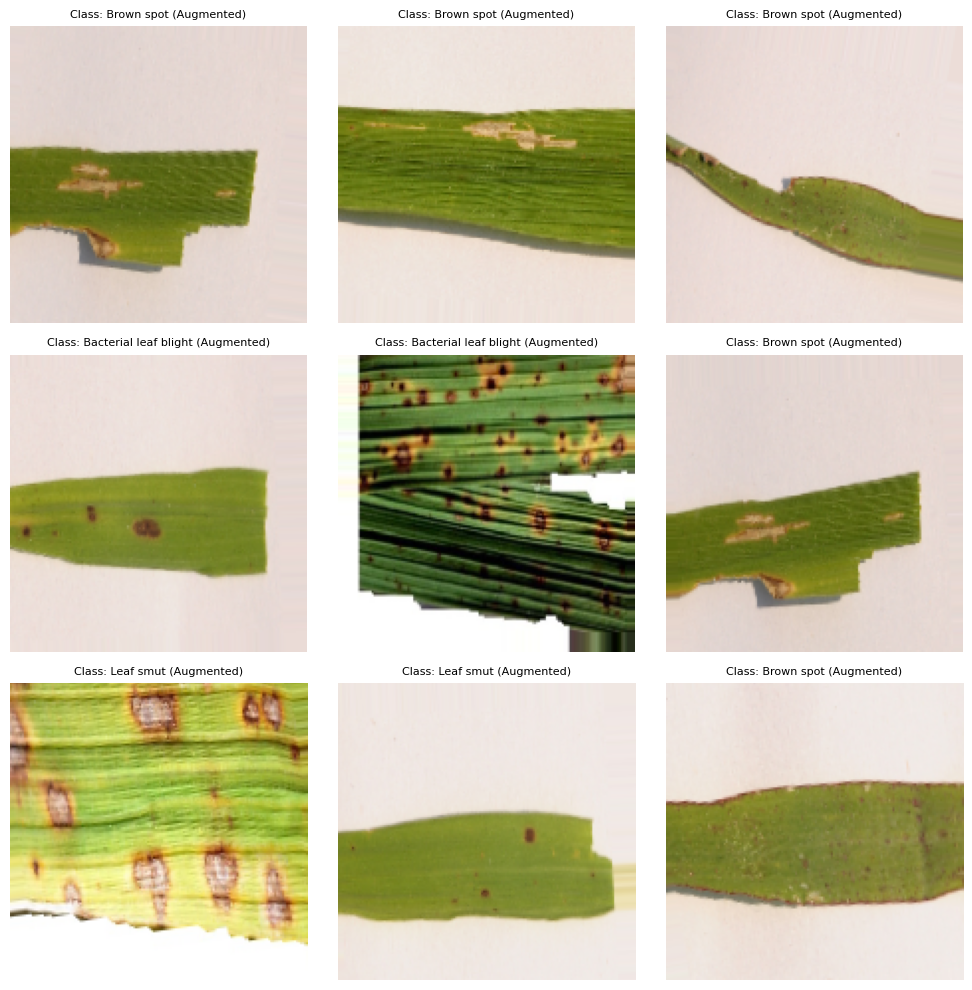

In [10]:
# Sample visualization
images, labels = next(train_generator)
plt.figure(figsize=(10, 10))
for i in range(9):
    augmented_images, _ = next(train_generator) # Generate a batch of augmented images
    plt.subplot(3, 3, i + 1) # Create a subplot for each image in a 3x3 grid
    plt.imshow(augmented_images[i]) # Display the augmented image
    # Get the corresponding label of the original image
    original_label = list(train_generator.class_indices.keys())[np.argmax(labels[i])]
    plt.title(f"Class: {original_label} (Augmented)", fontsize=8)  # Display the class label of the original image
    plt.axis('off')  # Hide axis labels
    
plt.tight_layout()
plt.show()

### 2.2.2 Model with Data Augmentation

In [11]:
# load validation data
val_datagen = ImageDataGenerator(rescale=1./255)
val_generator = val_datagen.flow_from_directory(
    'model_dataset/val',
    target_size=(150, 150),
    batch_size=batch_size,
    class_mode='categorical'
)

# Run the model
model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // batch_size,
    epochs=epoch_number,
    validation_data=val_generator,
    validation_steps=val_generator.samples // batch_size
)

# Evaluate on validation set
val_accuracy = model.evaluate(val_generator)[1] * 100
print(f"Validation accuracy with augmented data: {val_accuracy:.2f}%")

# Evaluate on test set
test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(
    'model_dataset/test',
    target_size=(150, 150),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

accuracy = model.evaluate(test_generator)[1] * 100
print(f"Test accuracy with augmented data: {accuracy:.2f}%")


Found 12 images belonging to 3 classes.
Epoch 1/20
2/2 [==============================] - 7s 4s/step - loss: 0.7285 - accuracy: 0.6667
Epoch 2/20
2/2 [==============================] - 7s 4s/step - loss: 0.7269 - accuracy: 0.6875
Epoch 3/20
2/2 [==============================] - 6s 3s/step - loss: 0.7876 - accuracy: 0.7031
Epoch 4/20
2/2 [==============================] - 6s 3s/step - loss: 0.7456 - accuracy: 0.6406
Epoch 5/20
2/2 [==============================] - 5s 3s/step - loss: 0.8276 - accuracy: 0.6825
Epoch 6/20
2/2 [==============================] - 6s 3s/step - loss: 0.6684 - accuracy: 0.7302
Epoch 7/20
2/2 [==============================] - 5s 3s/step - loss: 0.6539 - accuracy: 0.7143
Epoch 8/20
2/2 [==============================] - 6s 3s/step - loss: 0.6967 - accuracy: 0.6825
Epoch 9/20
2/2 [==============================] - 6s 3s/step - loss: 0.5807 - accuracy: 0.7460
Epoch 10/20
2/2 [==============================] - 7s 3s/step - loss: 0.5792 - accuracy: 0.7812
Epoch 11/

### By doing Augmentation, the accuracy is getting better.

## 2.3 Adding more layers on basic model

In [12]:
# Define CNN model architecture 
model = Sequential([
    # Convolutional layers with ReLU activation to extract features
    Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)), # 32 filters, 3x3 kernel, with 'relu' activation
    
    # Pooling layer that performs max pooling with a 2x2 pool size, reducing spatial dimensions and extracting dominant features.
    MaxPooling2D((2, 2)),     
    
    # Additional layers
    Conv2D(64, (3, 3), activation='relu'), # 63 filters, 3x3 kernel, with 'relu' activation
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'), # 128 filters, 3x3 kernel, with 'relu' activation
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'), # 128 filters, 3x3 kernel, with 'relu' activation
    MaxPooling2D((2, 2)),
        
    Flatten(), # Flattening layer to convert the 2D feature maps into a 1D vector
    Dense(128, activation='relu'), # Fully connected layers for classification
    Dense(3, activation='softmax')  # # Activation function for multiclass classification with 3 classes
])

# Compiling the model with 'adam' optimizer and 'categorical_crossentropy' loss for multiple classes
model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

# Display the model summary
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_1 (Conv2D)           (None, 148, 148, 32)      896       
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 74, 74, 32)        0         
 g2D)                                                            
                                                                 
 conv2d_2 (Conv2D)           (None, 72, 72, 64)        18496     
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 36, 36, 64)        0         
 g2D)                                                            
                                                                 
 conv2d_3 (Conv2D)           (None, 34, 34, 128)       73856     
                                                                 
 max_pooling2d_3 (MaxPoolin  (None, 17, 17, 128)      

In [13]:
# Run the model
model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // batch_size,
    epochs=epoch_number,
    validation_data=val_generator,
    validation_steps=val_generator.samples // batch_size
)

# Evaluate on validation set
val_accuracy = model.evaluate(val_generator)[1] * 100
print(f"Validation accuracy with more layers: {val_accuracy:.2f}%")

# Calculate accuracy
accuracy = model.evaluate(test_generator)[1] * 100
print(f"Test accuracy with more layers: {accuracy:.2f}%")


Epoch 1/20
2/2 [==============================] - 11s 5s/step - loss: 1.1059 - accuracy: 0.3750
Epoch 2/20
2/2 [==============================] - 8s 4s/step - loss: 1.1320 - accuracy: 0.3651
Epoch 3/20
2/2 [==============================] - 6s 3s/step - loss: 1.0969 - accuracy: 0.3016
Epoch 4/20
2/2 [==============================] - 7s 3s/step - loss: 1.1150 - accuracy: 0.3333
Epoch 5/20
2/2 [==============================] - 8s 4s/step - loss: 1.0846 - accuracy: 0.3750
Epoch 6/20
2/2 [==============================] - 7s 3s/step - loss: 1.0824 - accuracy: 0.3810
Epoch 7/20
2/2 [==============================] - 7s 4s/step - loss: 1.0761 - accuracy: 0.4762
Epoch 8/20
2/2 [==============================] - 8s 4s/step - loss: 1.0711 - accuracy: 0.3906
Epoch 9/20
2/2 [==============================] - 7s 3s/step - loss: 1.0323 - accuracy: 0.6190
Epoch 10/20
2/2 [==============================] - 7s 4s/step - loss: 0.9531 - accuracy: 0.5625
Epoch 11/20
2/2 [==============================]

### Adding more layers not always produce higher accuracy. In this case, by adding more layers the accuracy getting lower.

## 2.4 Use Transfer Learning 
Transfer learning is a machine learning technique where a model trained on one task is repurposed or fine-tuned on a second related task. Instead of training a model from scratch, transfer learning utilizes knowledge gained from solving one problem and applies it to a different but related problem.
Utilize a pre-trained models (like VGG, ResNet, Inception, etc.) as a starting point. For starter we use VGG16 (Visual Geometry Group)

### 2.4.1 Use VGG Pre-Trained Model

In [14]:
# Import additional modules
from tensorflow.keras.applications import VGG16

In [ ]:
# Load the pre-trained VGG16 model without the top (fully connected) layers
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(150, 150, 3))

# Freeze the base model layers
for layer in base_model.layers:
    layer.trainable = False

# Create a new model on top of the pre-trained base model
model = Sequential([
    base_model,
    Flatten(),
    Dense(256, activation='relu'),
    Dense(3, activation='softmax')  
])

# Compile the model
model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

# Display the model summary
model.summary()

# Run the model
model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // batch_size,
    epochs=epoch_number,
    validation_data=val_generator,
    validation_steps=val_generator.samples // batch_size
)

# Evaluate on validation set
val_accuracy = model.evaluate(val_generator)[1] * 100
print(f"Validation accuracy with Transfer Learning : {val_accuracy:.2f}%")

# Calculate test accuracy
accuracy = model.evaluate(test_generator)[1] * 100
print(f"Test accuracy Transfer Learning: {accuracy:.2f}%")


Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg16 (Functional)          (None, 4, 4, 512)         14714688  
                                                                 
 flatten_2 (Flatten)         (None, 8192)              0         
                                                                 
 dense_4 (Dense)             (None, 256)               2097408   
                                                                 
 dense_5 (Dense)             (None, 3)                 771       
                                                                 
Total params: 16812867 (64.14 MB)
Trainable params: 2098179 (8.00 MB)
Non-trainable params: 14714688 (56.13 MB)
_________________________________________________________________
Epoch 1/20
1/2 [==============>...............] - ETA: 12s - loss: 1.2048 - accuracy: 0.3438

### Using pre-trained model increases the accuracy

### 2.4.2 Iterate Pre-Trained Model

In [ ]:
# Import other pre-trained modules
from tensorflow.keras.applications import MobileNetV2, ResNet50, InceptionV3

In [ ]:
pretrained_models = [VGG16, MobileNetV2, ResNet50, InceptionV3]  # pre-trained models to iterate over

for pretrained_model in pretrained_models:
    # Record the start time
    start_time = time.time()
    
    base_model = pretrained_model(weights='imagenet', include_top=False, input_shape=(150, 150, 3))
    
    for layer in base_model.layers:
        layer.trainable = False
    
    # Create a new model on top of the pre-trained base model
    model = Sequential([
        base_model,
        Flatten(),
        Dense(256, activation='relu'),
        Dense(3, activation='softmax')  
        ])

    # Compile the model
    model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])
    
    # Run the model
    model.fit(
        train_generator,
        steps_per_epoch=train_generator.samples // batch_size,
        epochs=epoch_number,
        validation_data=val_generator,
        validation_steps=val_generator.samples // batch_size
        )

    # Evaluate on validation set
    val_accuracy = model.evaluate(val_generator)[1] * 100
    print(f"Validation accuracy: {val_accuracy:.2f}%")
  
    # Evaluate model performance
    loss, accuracy = model.evaluate(test_generator)
    print(f"Pre-trained Model: {pretrained_model.__name__} - Test Accuracy: {accuracy}")
    
    # Record the end time after training
    end_time = time.time()

    # Calculate the total time taken
    total_time = end_time - start_time
    print(f"Total time taken for Pre-trained Model: {pretrained_model.__name__}: {total_time:.2f} seconds")

### Using pre-trained model (except for ResNet50) increase the accuracy. MobileNetV2 and InceptionV3 gave the highest validation accuracy (91%). We will use InceptionV3 for the next model


## 2.5 Add Dropout
Dropout is a regularization technique used in neural networks, including Convolutional Neural Networks (CNNs), to prevent overfitting and improve the generalization of the model. Overfitting occurs when a model learns too much from the training data, including the noise or random fluctuations present in the data, making it perform poorly on unseen or test data.

In [ ]:
from tensorflow.keras.layers import Dropout

In [ ]:
# Load the pre-trained InceptionV3 model without the top (fully connected) layers
base_model = InceptionV3(weights='imagenet', include_top=False, input_shape=(150, 150, 3))

# Freeze the base model layers
for layer in base_model.layers:
    layer.trainable = False

# Create a new model on top of the pre-trained base model
model = Sequential([
    base_model,
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5), # randomly sets 50% of the input units inactive
    Dense(3, activation='softmax')  
])

# Compile the model
model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

# Display the model summary
model.summary()

# Run the model
model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // batch_size,
    epochs=epoch_number,
    validation_data=val_generator,
    validation_steps=val_generator.samples // batch_size
)

# Evaluate on validation set
val_accuracy = model.evaluate(val_generator)[1] * 100
print(f"Validation accuracy with DropOut: {val_accuracy:.2f}%")

# Calculate accuracy
accuracy = model.evaluate(test_generator)[1] * 100
print(f"Test accuracy with DropOut: {accuracy:.2f}%")


In [ ]:
# Iterate DropOut Value

dropout_value = [0.3, 0.4, 0.5, 0.6]  # DropOut value to iterate

for drop_val in dropout_value:
    # Create the model
    model = Sequential([
    base_model,
    Flatten(),
    Dense(64, activation='relu'), 
    Dropout(drop_val), 
    Dense(3, activation='softmax') # Output layer
])

    model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])
    
    # Train the model
    history = model.fit(
        train_generator,
        steps_per_epoch=train_generator.samples // batch_size,
        epochs=epoch_number,
        validation_data=val_generator,
        validation_steps=val_generator.samples // batch_size,
        verbose=0  # You can change verbosity to see training progress
    )
    
    # Evaluate model performance
    loss, accuracy = model.evaluate(test_generator)
    print(f"DropOut value: {drop_val} - Test Accuracy: {accuracy}")

### DropOut value 0.3 give the best accuracy (100%). We will use DropOut value = 0.3 onward

## 2.6 Add & Iterate Learning Rate
The learning rate is a hyperparameter in machine learning models that determines the step size taken during the optimization process, such as gradient descent, to update the weights of the model.
Choosing an appropriate learning rate is crucial for effective model training:
- Too high a learning rate might cause the model to oscillate or overshoot the optimal solution.
- Too low a learning rate might lead to slow convergence or getting stuck in suboptimal solutions.

In [ ]:
drop_val = 0.3
learning_rates = [0.01, 0.001, 0.0001]  # learning rates to iterate over

for lr in learning_rates:
    # Create the model
    model = Sequential([
    base_model,
    Flatten(),
    Dense(64, activation='relu'), 
    Dropout(drop_val), 
    Dense(3, activation='softmax') # Output layer
])

    model.compile(optimizer=Adam(learning_rate=lr), loss='categorical_crossentropy', metrics=['accuracy'])
    
    # Train the model
    history = model.fit(
        train_generator,
        steps_per_epoch=train_generator.samples // batch_size,
        epochs=epoch_number,
        validation_data=val_generator,
        validation_steps=val_generator.samples // batch_size,
        verbose=0  # You can change verbosity to see training progress
    )
    
    # Evaluate model performance
    loss, accuracy = model.evaluate(test_generator)
    print(f"Learning Rate: {lr} - Test Accuracy: {accuracy}")


### Best learning rate = 0.001 (default value)

## 2.7 Add & Iterate Regularizers L2
L2 regularization are techniques used to prevent overfitting in machine learning models, including neural networks. They work by adding penalty terms to the loss function based on the magnitudes of the model's weights.

In [ ]:
from tensorflow.keras import regularizers

In [ ]:
lr = 0.001
l2_value = [0.1, 0.01, 0.001]  # L2 value to iterate over

for l2_val in l2_value:
    # Create the model
    model = Sequential([
    base_model,
    Flatten(),
    Dense(64, activation='relu', kernel_regularizer=regularizers.l2(l2_val)), # applies L2 regularization to the weights of the layer
    Dropout(drop_val), 
    Dense(3, activation='softmax') # Output layer
])

    model.compile(optimizer=Adam(learning_rate=lr), loss='categorical_crossentropy', metrics=['accuracy'])
    
    # Train the model
    history = model.fit(
        train_generator,
        steps_per_epoch=train_generator.samples // batch_size,
        epochs=epoch_number,
        validation_data=val_generator,
        validation_steps=val_generator.samples // batch_size,
        verbose=0  # You can change verbosity to see training progress
    )
    
    # Evaluate model performance
    loss, accuracy = model.evaluate(test_generator)
    print(f"L2 value: {l2_val} - Test Accuracy: {accuracy}")


### Best L2 Value is 0.01. We will use L2 value = 0.01 (default value) for the next model

## 2.8 Fine tuning some layers
When you freeze layers, it means these layers are excluded from the training process, and their weights remain fixed or unchanged during subsequent training. Only the weights of the unfrozen (trainable) layers are updated using backpropagation.
This approach is particularly useful when dealing with limited amounts of data for the new task, preventing the risk of overfitting the model to the new data while benefiting from the learned representations of the pre-trained model.

In [ ]:
l2_val = 0.01
# Iterate over different freeze_until_layer values
best_accuracy = 0.0
best_freeze_layer = None


for freeze_until_layer in range(10, 150, 10):
    # Base Model
    base_model = InceptionV3(weights='imagenet', include_top=False, input_shape=(150, 150, 3)) 
    
    # Freeze some initial layers of the base model and fine-tune the rest
    for layer in base_model.layers[:freeze_until_layer]:
        layer.trainable = False

    # Create a new model on top of the pre-trained base model
    model = Sequential([
        base_model,
        Flatten(),
        Dense(256, activation='relu', kernel_regularizer=regularizers.l2(l2_val)),
        Dropout(drop_val), 
        Dense(3, activation='softmax')  
        ])

    # Compile the model
    model.compile(optimizer=Adam(learning_rate=lr), loss='categorical_crossentropy', metrics=['accuracy'])
    
    # Run the model
    model.fit(
        train_generator,
        steps_per_epoch=train_generator.samples // batch_size,
        epochs=epoch_number,
        validation_data=val_generator,
        validation_steps=val_generator.samples // batch_size,
        verbose=0
        )

    
    # Evaluate model on test data
    loss, accuracy = model.evaluate(test_generator)
    print(f"Freeze until layer {freeze_until_layer}: Test Accuracy: {accuracy}")
    
    # Check for the best accuracy and corresponding freeze_until_layer value
    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_freeze_layer = freeze_until_layer

print(f"Best accuracy: {best_accuracy} obtained at freeze_until_layer: {best_freeze_layer}")

#### Best accuracy: 66.67% obtained almost at every freeze_until_layer: 120 
### We will not freeze layers as it is decrease the accuracy

In [ ]:
l2_val = 0.01

# Base Model
base_model = InceptionV3(weights='imagenet', include_top=False, input_shape=(150, 150, 3)) 
    
# Freeze some layers
for layer in base_model.layers:
    layer.trainable = False

# Create a new model on top of the pre-trained base model
model = Sequential([
        base_model,
        Flatten(),
        Dense(64, activation='relu', kernel_regularizer=regularizers.l2(l2_val)), 
        Dropout(drop_val),
        Dense(3, activation='softmax') 
        ])

# Compile the model
model.compile(optimizer=Adam(learning_rate=lr), loss='categorical_crossentropy', metrics=['accuracy'])

# Run the model
model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // batch_size,
    epochs=epoch_number,
    validation_data=val_generator,
    validation_steps=val_generator.samples // batch_size
)

# Evaluation on validation set
val_accuracy = model.evaluate(val_generator)[1] * 100
print(f"Validation accuracy: {val_accuracy:.2f}%")

# Calculate the test accuracy
accuracy = model.evaluate(test_generator)[1] * 100
print(f"Test accuracy: {accuracy:.2f}%")


## 2.9 Add Batch Normalization
By inserting BatchNormalization() after the dropout layer and before the final output layer, it will allow the model to normalize the activations of the previous layer before passing them to the output layer. This can help improve the stability and generalization of the model during training.

In [ ]:
from tensorflow.keras.layers import BatchNormalization

In [ ]:
# Base Model
base_model = InceptionV3(weights='imagenet', include_top=False, input_shape=(150, 150, 3)) 
    
# Freeze some layers
for layer in base_model.layers:
    layer.trainable = False

# Create a new model on top of the pre-trained base model
model = Sequential([
        base_model,
        Flatten(),
        Dense(64, activation='relu', kernel_regularizer=regularizers.l2(l2_val)), 
        Dropout(drop_val), 
        
        BatchNormalization(),  # Add Batch Normalization here
    
        Dense(3, activation='softmax') 
        ])

# Compile the model
model.compile(optimizer=Adam(learning_rate=lr), loss='categorical_crossentropy', metrics=['accuracy'])

# Display the model summary
model.summary()

# Run the model
model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // batch_size,
    epochs=epoch_number,
    validation_data=val_generator,
    validation_steps=val_generator.samples // batch_size
)

# Evaluation on validation set
val_accuracy = model.evaluate(val_generator)[1] * 100
print(f"Validation accuracy: {val_accuracy:.2f}%")

# Calculate the test accuracy
accuracy = model.evaluate(test_generator)[1] * 100
print(f"Test accuracy: {accuracy:.2f}%")


### With BatchNormalization, the test accuracy is increased.

## 2.10 Add Callback (with EarlyStopping) & ModelCheckPoint
Too many epochs can lead to overfitting of the training dataset, whereas too few may result in an underfit model. Early stopping is a method to specify an arbitrary large number of training epochs and stop training once the model performance stops improving on a hold out validation dataset. It also save computational resources by stopping the training process once a monitored metric (like validation loss or accuracy) stops improving.
The EarlyStopping callback will stop training once triggered, but the model at the end of training may not be the model with best performance on the validation dataset.
An additional callback is required that will save the best model observed during training for later use. This is the ModelCheckpoint callback.

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [ ]:
# Record the start time
start_time = time.time()

# Base Model
base_model = InceptionV3(weights='imagenet', include_top=False, input_shape=(150, 150, 3)) 
    
# Freeze some layers
for layer in base_model.layers:
    layer.trainable = False

# Create the model
model = Sequential([
    base_model,
    Flatten(),
    Dense(128, activation='relu', kernel_regularizer=regularizers.l2(l2_val)), 
    Dropout(drop_val), 
    BatchNormalization(),  # Add Batch Normalization here
    Dense(3, activation='softmax') # Output layer
])

# Define EarlyStopping callback
early_stopping = EarlyStopping(
    monitor='accuracy',  # Metric to monitor for improvement
    patience=5,           # Number of epochs with no improvement after which training will be stopped
    restore_best_weights=True  # Restore model weights to the point of best validation loss
)

# Define ModelCheckpoint callback to save best model in native Keras format
checkpoint = ModelCheckpoint(
    'best_model.h5',  # Filepath to save the best model weights
    monitor='accuracy',  # Metric to monitor (e.g., validation loss)
    save_best_only=True,  # Save only the best model (based on the monitored metric)
    mode='max',  # Mode for the monitored metric (e.g., 'min' for loss, 'max' for accuracy)
)

# Compile the model
model.compile(optimizer=Adam(learning_rate=lr), loss='categorical_crossentropy', metrics=['accuracy'])

# Display the model summary
model.summary()

# Train the model with EarlyStopping callback
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // batch_size,
    epochs=epoch_number,  # Use a larger number of epochs than the patience
    validation_data=val_generator,
    validation_steps=val_generator.samples // batch_size,
    callbacks=[early_stopping, checkpoint]  # Pass EarlyStopping and CheckPoint callback to the callbacks list
)

# Access final training accuracy from history
final_train_accuracy = history.history['accuracy'][-1]
print(f"Final Training Accuracy: {final_train_accuracy:.4f}")

# Evaluation on validation set
val_accuracy = model.evaluate(val_generator)[1] * 100
print(f"Validation accuracy with CallBack: {val_accuracy:.2f}%")

# Calculate the test accuracy
accuracy = model.evaluate(test_generator)[1] * 100
print(f"Test accuracy with CallBack: {accuracy:.2f}%")

# Record the end time after training
end_time = time.time()

# Calculate the total time taken
total_time = end_time - start_time
print(f"Total time taken for Model: {total_time:.2f} seconds")

In [ ]:
# Access training/validation accuracy from history
train_accuracy = history.history['accuracy']
val_accuracy = history.history.get('val_accuracy') or history.history.get('val_acc')

# Access final training accuracy from history
final_train_accuracy = history.history['accuracy'][-1]
print(f"Final Training Accuracy: {final_train_accuracy:.4f}")

print(f"Test accuracy: {accuracy:.2f}%")

# Test accuracy obtained previously
test_accuracy = model.evaluate(test_generator)[1]

# Number of epochs
epochs = range(1, len(train_accuracy) + 1)

plt.figure(figsize=(10, 6))

# Plotting accuracy over epochs if available
plt.plot(epochs, train_accuracy, 'b', label='Training Accuracy')

# why the val_accuracy not shown?
# if val_accuracy is not None:
#    plt.plot(epochs, val_accuracy, 'r', label='Validation Accuracy')

# Plotting test accuracy as a horizontal line across epochs
plt.axhline(y=test_accuracy, color='g', linestyle='--', label='Test Accuracy')
plt.xticks(list(range(1, len(epochs) + 1)))
plt.title('Training, Validation, and Test Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')

plt.legend()
plt.grid(True)
plt.show()


## 3. Load and test the model 
We will load the model and test our data which has been splitted earlier on above step.

### 3.1 Load the model

In [ ]:
# import module
from tensorflow.keras.models import load_model

In [ ]:
# Load the saved model from the .h5 file
model = load_model('best_model.h5')

### 3.2 Test Our Model

In [ ]:
# Directory of our test data
test_path = 'model_dataset/test'

In [ ]:
# Define function to test and visualize images
def test_and_visualize_images():
    classes = os.listdir(test_path) # classes of our data (leaf blast, bacterial blight and brown spot)
    fig, axs = plt.subplots(nrows=len(classes), ncols=3, figsize=(10, 10)) # Creates a grid of subplots for visualizing images

    for i, disease_class in enumerate(classes): # Iterates through each class of images
        class_path = os.path.join(test_path, disease_class) # Forms the path to the specific class folder within the test directory
        images = os.listdir(class_path) # Retrieves a list of image file names in the current class folder
        sample_images = images[:3] # taking first three samples

        for j, img_name in enumerate(sample_images): # inner loop
            img_path = os.path.join(class_path, img_name) # Constructs the path to the current image within the class folder
            img = Image.open(img_path)  # Open the image using PIL
            img = img.resize((150, 150))  # Resize the image
            img_array = np.array(img) # Converts the image to a NumPy array
            img_array = np.expand_dims(img_array, axis=0) # Reshapes the array to have a batch dimension (required by the model)
            img_array = img_array.astype('float32') / 255.0  # Normalize the image data

            # Make predictions
            prediction = model.predict(img_array) # Uses the loaded model to make predictions on the image
            predicted_class = np.argmax(prediction) # Determines the predicted class 

            # Determine title and title color based on prediction accuracy, blue if correct, red if wrong
            title = f"Pred: {classes[predicted_class]} | Actual: {disease_class}"
            title_color = 'blue' if predicted_class == classes.index(disease_class) else 'red'

            # Display the image
            axs[i, j].imshow(img)
            axs[i, j].set_title(title, color=title_color, fontsize=8)
            axs[i, j].axis('off')

    plt.tight_layout()
    plt.show()

# Test and visualize images
test_and_visualize_images()


## Conclusion :
1. CNN (Convolutional Neural Network) is a powerful machine learning model that can classify images with high accuracy. 
2. With a basic model no augmentation yet, the result is still high (66% on validation accuracy, 91% on test accuracy). However, due to the small data size, the model is overfitting.
3. We can reduce overfitting and increase the accuracy by some techniques (Data Augmentation, Adding more layers, use Transfer Learning, DropOut, Learning rate and Regularization, and Batch Normalization. 
4. Not all above techiques always improve the accuracy. We have to try and check the result on every step to get the best results.
5. In separate work (last columns), We did GridSearchCV over two parameters (3 batch sizes and 3 epochs) and it is very computational cost (took 4 HOURS to complete the iteration). 
6. Specific to this project, we use a combination of Data Augmentation, use Transfer Learning and Batch Normalization techniques to reduce the overfitting. For DropOut, Learning rate and Regularizer L2 the best parameters are the same as the default value. By adding EarlyStopping and ModelCheckPoint, we got a train accuracy 96%, validation accuracy 91% and test accuracy 83%. We confirmed also by load and test the model, and the results are perfectly fine.

## Addition Note: GridSearchCV - purposely intended place at the bottom-
GridSearchCV is a technique used for hyperparameter optimization, where it is systematically search through a specified parameter grid to find the best combination of hyperparameters for a machine learning model. However it is very computational cost and memory consuming. For the model below, it took 4 Hours to complete over 2 parameters.

For a Convolutional Neural Network (CNN), there are several parameters we might consider tuning using GridSearchCV:
- Number of Filters (or Kernel Size): The number of filters in each convolutional layer.
- Kernel/Filter Size: The size of the filter used in the convolutional layers.
- Pooling: Parameters related to pooling layers, such as the type of pooling (max pooling, average pooling) and its size.
- Learning Rate: Rate at which the model's weights are updated during training.
- Activation Functions: The choice of activation functions in different layers (ReLU, tanh, sigmoid, etc.).
- Dropout Rate: A regularization technique to prevent overfitting by randomly setting a fraction of input units to 0 at each update during training.
- Optimizer: The optimization algorithm used (Adam, SGD, RMSprop, etc.).
- Batch Size: The number of samples used in each iteration during training.
- Number of Epochs: The number of passes through the entire training dataset during training.

We already tried to configure the parameter to be search, but we can't search optimal parameter for 'neurons', 'activation', 'optimizer', 'DropOut' as they have to be specified on the model we create. As for examples, we use parameter 'epochs' and 'batch_size'

In [ ]:
from sklearn.model_selection import GridSearchCV
from scikeras.wrappers import KerasClassifier
from tensorflow.keras.layers import GlobalAveragePooling2D
import itertools

In [ ]:
---WARNING---
---DO NOT RUN THIS STEP--
---IT WILL TAKE 4 HOURS TO FINISH THE ITERATION---


# Record the start time
start_time = time.time()

# Data augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Load data and train the model
train_generator = train_datagen.flow_from_directory(
    'model_dataset/train',
    target_size=(150, 150),
    batch_size=batch_size,
    class_mode='categorical'
)

# load validation data
val_datagen = ImageDataGenerator(rescale=1./255)
val_generator = val_datagen.flow_from_directory(
    'model_dataset/val',
    target_size=(150, 150),
    batch_size=batch_size,
    class_mode='categorical'
)

# Evaluate on test set
test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(
    'model_dataset/test',
    target_size=(150, 150),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

num_classes = 3

# Define a function that creates a model (required by KerasClassifier)
def create_model(dropout_rate=0.3, neurons=256, activation='relu', optimizer='adam'): 
    base_model = InceptionV3(weights='imagenet', include_top=False, input_shape=(150, 150, 3))
    
    for layer in base_model.layers:
        layer.trainable = False
    model = Sequential([
        base_model, 
        # Add layers based on parameters
        GlobalAveragePooling2D(),
        Flatten(),
        Dense(neurons, activation=activation),
        Dense(num_classes, activation='softmax')
        ])
    model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
        
    return model

# Wrap Keras model so it can be used by scikit-learn
keras_model = KerasClassifier(model=create_model)

# Define hyperparameters to search
param_grid = {
    'epochs' : [10, 20, 30],
    'batch_size': [16, 32, 64]
            }

# Create combinations of parameter values
param_combinations = list(itertools.product(*(param_grid[params] for params in param_grid)))

# Display the combinations of parameters being searched
for i, param_combination in enumerate(param_combinations):
    print(f"Grid search iteration {i+1}: {param_combination}")

    # Create GridSearchCV object
    grid = GridSearchCV(estimator=keras_model, param_grid=param_grid, cv=3, error_score='raise', scoring='accuracy')
    grid_result = grid.fit(train_generator[0][0], train_generator[0][1])  # Passing X and y

# Get the best parameters and accuracy
print("Best Parameters:", grid_result.best_params_)
print("Best Accuracy:", grid_result.best_score_)

# Record the end time after training
end_time = time.time()

# Calculate the total time taken
total_time = end_time - start_time
print(f"Total time taken for running GridSearchCV: {total_time:.2f} seconds")
